In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler  
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
redwine_df = pd.read_csv("winequality-red.csv")
redwine_df = redwine_df.replace(["", " ", "NA", "N/A", "null", "None", "?"], pd.NA)

print("DATA SET INFO: ")
redwine_df.info()



DATA SET INFO: 
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


Before Outlier Removal:


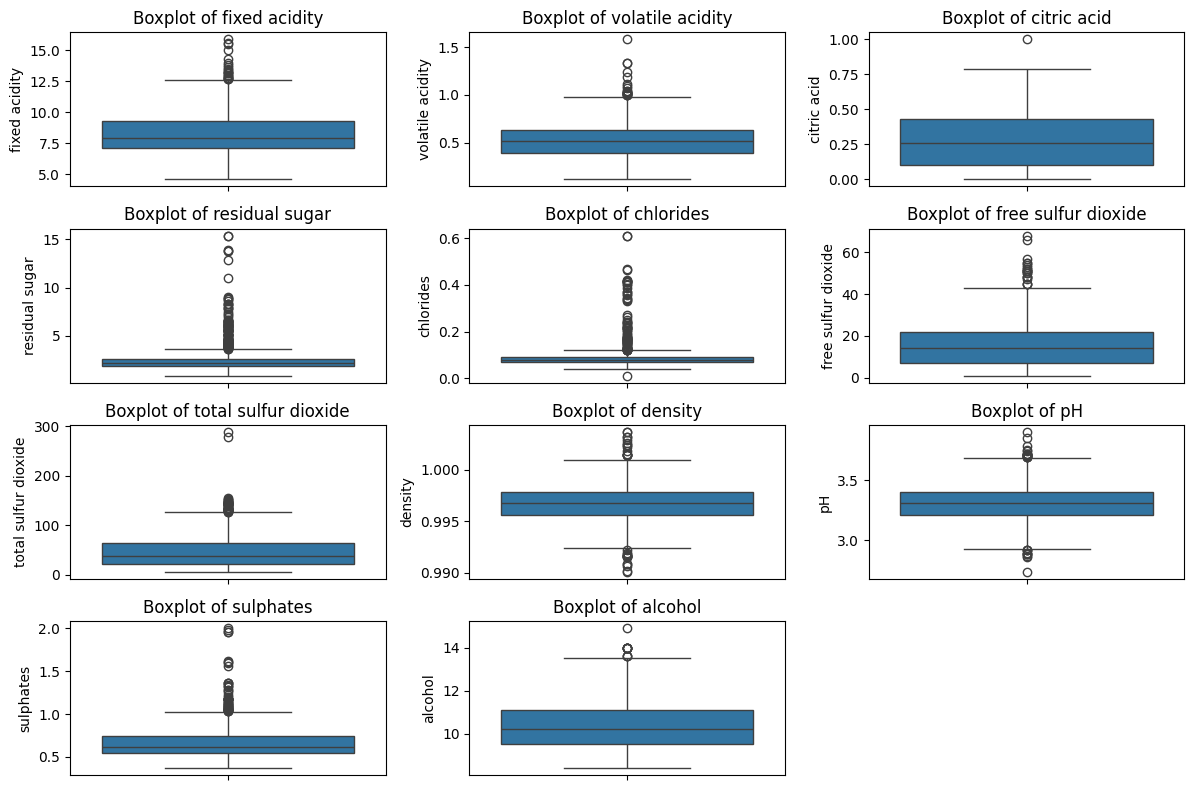

After Outlier Removal


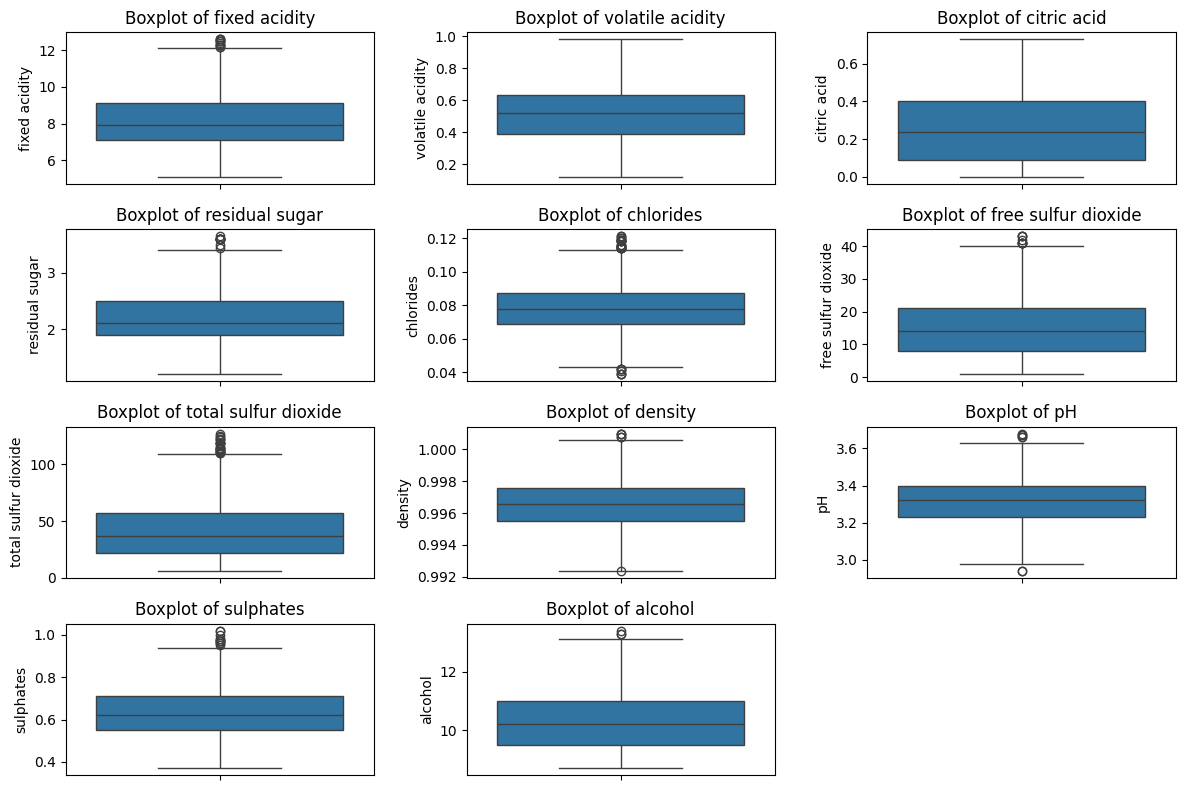

In [3]:
target_col = "quality"
X_all = redwine_df.drop(target_col, axis=1)
y_all = redwine_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

print("Before Outlier Removal:")
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4,3,i)
    sns.boxplot(y=X_train[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

def remove_outliers_iqr(df, cols, k=1.5):
    mask = pd.Series(True, index=df.index)
    for c in cols:
        q1 = df[c].quantile(0.25)
        q3 = df[c].quantile(0.75)
        iqr = q3 - q1
        low = q1 - k * iqr
        high = q3 + k * iqr
        mask &= df[c].between(low, high) | df[c].isna()
    return mask

train_mask = remove_outliers_iqr(X_train, num_cols)
X_train = X_train.loc[train_mask].reset_index(drop=True)
y_train = y_train.loc[train_mask].reset_index(drop=True)

print(f"After Outlier Removal")
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4,3,i)
    sns.boxplot(y=X_train[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

num_imputer = SimpleImputer(strategy="median")
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
kernels = ["linear", "poly", "rbf", "sigmoid"]
c_values = [0.1, 1, 10]

results = []

for kernel in kernels:
    for i, c in enumerate(c_values, start=1):
        c_label = f"c{i}"
        model = SVR(kernel=kernel, C=c)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        mse = mean_squared_error(y_test, y_pred)

        results.append({
            "Type of Kernel": kernel.capitalize(),
            "c_label": c_label,
            "C": c,
            "MSE_Result" : round(mse, 4)
        })

results_df = pd.DataFrame(results)
results_df



,Type of Kernel,c_label,C,MSE_Result
0,Linear,c1,0.1,0.4091
1,Linear,c2,1.0,0.4089
2,Linear,c3,10.0,0.4090
3,Poly,c1,0.1,88.2973
4,Poly,c2,1.0,252.6583
5,Poly,c3,10.0,2194.9995
6,Rbf,c1,0.1,0.4687
7,Rbf,c2,1.0,0.4613
8,Rbf,c3,10.0,0.5744
9,Sigmoid,c1,0.1,1.4727


In [6]:
results_table = results_df.pivot(index="Type of Kernel", columns="c_label", values="MSE_Result")
results_table = results_table.reindex(index=["Linear", "Poly", "Rbf", "Sigmoid"])
for i, c in enumerate(c_values):
    print(f"c{i+1} = {c}")
results_table

c1 = 0.1
c2 = 1
c3 = 10


c_label,c1,c2,c3
Type of Kernel,,,
Linear,0.4091,0.4089,0.4090
Poly,88.2973,252.6583,2194.9995
Rbf,0.4687,0.4613,0.5744
Sigmoid,1.4727,252.5492,25885.2529


In [7]:
best_row = results_df.loc[results_df["MSE_Result"].idxmin()]
best_kernel = best_row["Type of Kernel"].lower()
best_c = best_row["C"]

best_model = SVR(kernel=best_kernel, C=best_c)
best_model.fit(X_train_scaled, y_train)

print(f"Best SVM: kernel = {best_kernel} \nC = {best_c}\nMSE = {best_row['MSE_Result']}")
new_X = [[7.5,0.5,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.8,10.5],
         [10, 1, 3, 10, 0.23, 20, 120, 0.2314, 6, 0.12, 10]]
new_X_scaled = scaler.transform(new_X)
print("Sample Prediction with new Inputs: ")

predictions = best_model.predict(new_X_scaled)

for prediction in predictions:
    print("Predicted Wine Quality: ", round(prediction, 4))

Best SVM: kernel = linear 
C = 1.0
MSE = 0.4089
Sample Prediction with new Inputs: 
Predicted Wine Quality:  5.8991
Predicted Wine Quality:  10.5393


d:\Python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
